# Data Discovery

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
class WaterDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.tif")), key=lambda x: int(os.path.basename(x).split(".")[0]))
        self.label_paths = sorted(glob(os.path.join(label_dir, "*.png")), key=lambda x: int(os.path.basename(x).split(".")[0]))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load multispectral image
        with rasterio.open(self.image_paths[idx]) as src:
            img = src.read()  # shape: (bands, H, W)
        
        # Load label
        label = np.array(Image.open(self.label_paths[idx]))  # shape: (H, W)
        
        if self.transform:
            img, label = self.transform(img, label)
        
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [3]:
data_dir = "/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data"
image_dir = os.path.join(data_dir, "images")
label_dir = os.path.join(data_dir, "labels")

dataset = WaterDataset(image_dir, label_dir)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


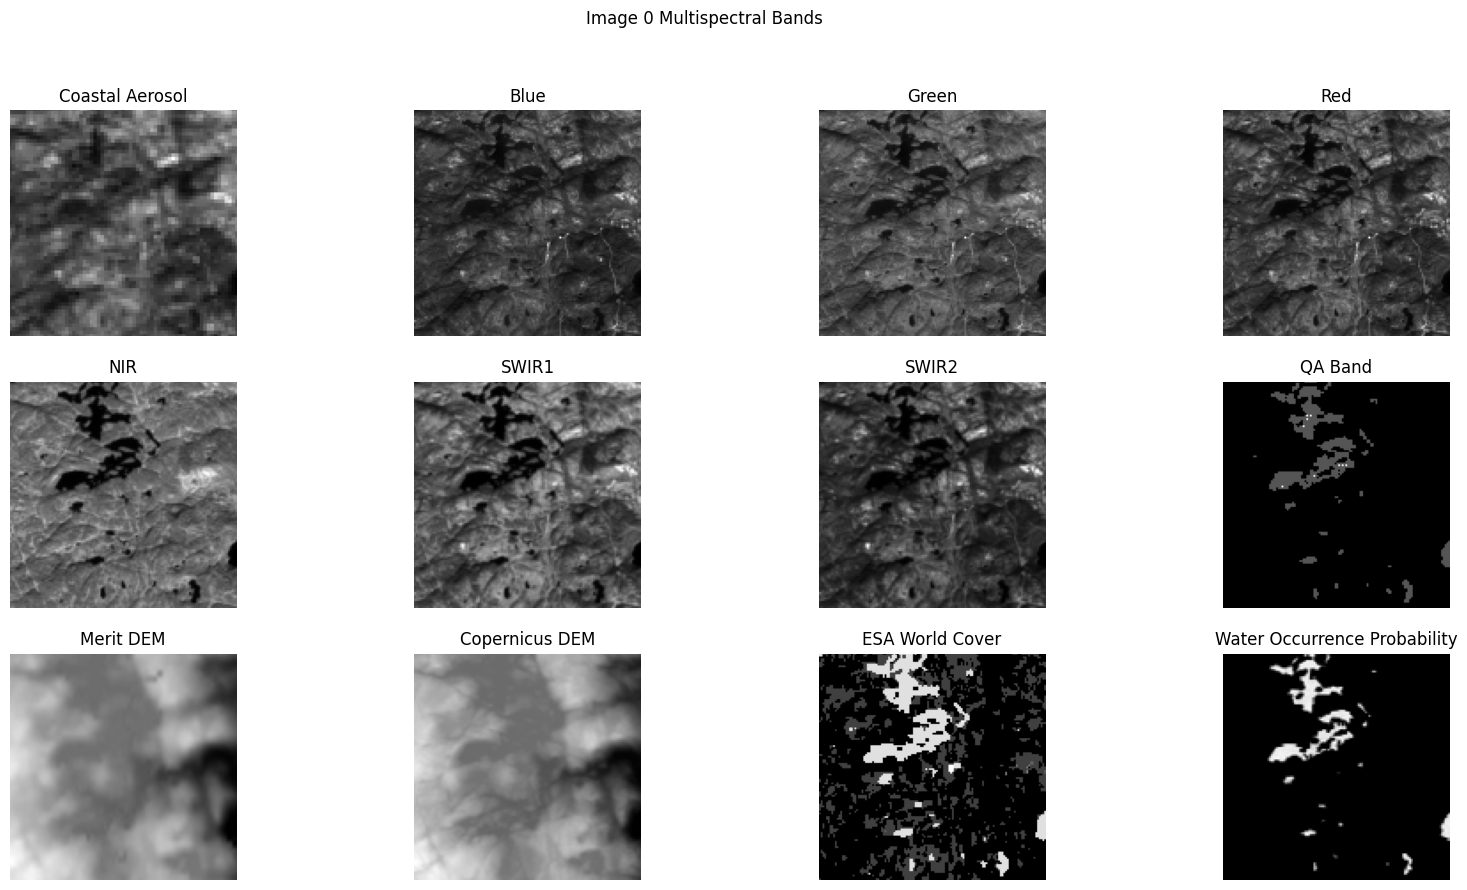

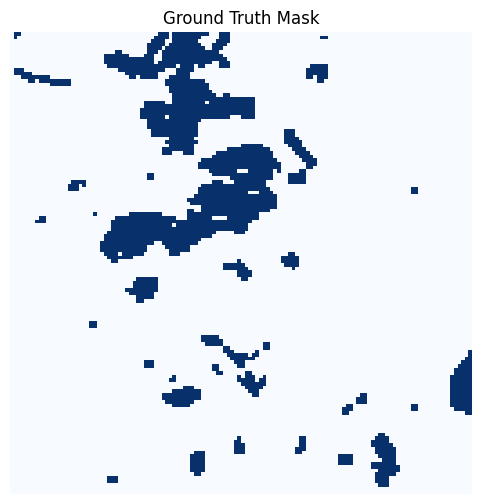

In [4]:
def plot_multispectral_bands(img, title=""):
    bands_names = [
        "Coastal Aerosol", "Blue", "Green", "Red", "NIR",
        "SWIR1", "SWIR2", "QA Band", "Merit DEM",
        "Copernicus DEM", "ESA World Cover", "Water Occurrence Probability"
    ]
    
    n_bands = img.shape[0]
    plt.figure(figsize=(20, 10))
    for i in range(n_bands):
        plt.subplot(3, 4, i+1)
        plt.imshow(img[i], cmap='gray')
        plt.title(bands_names[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Example visualization for the first sample
img, label = dataset[0]
plot_multispectral_bands(img.numpy(), title="Image 0 Multispectral Bands")

plt.figure(figsize=(6,6))
plt.imshow(label.numpy(), cmap='Blues')
plt.title("Ground Truth Mask")
plt.axis('off')
plt.show()


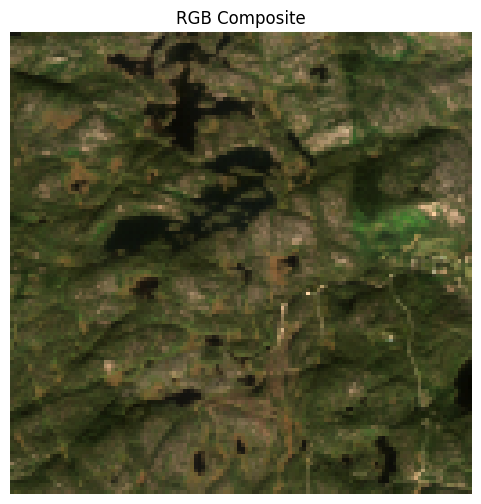

In [5]:
def plot_rgb_only(img):

    rgb = np.stack([img[3], img[2], img[1]], axis=-1)
    
    # Normalize for visualization
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title("RGB Composite")
    plt.axis('off')
    plt.show()

# Example for first image
img, _ = dataset[0]
plot_rgb_only(img.numpy())

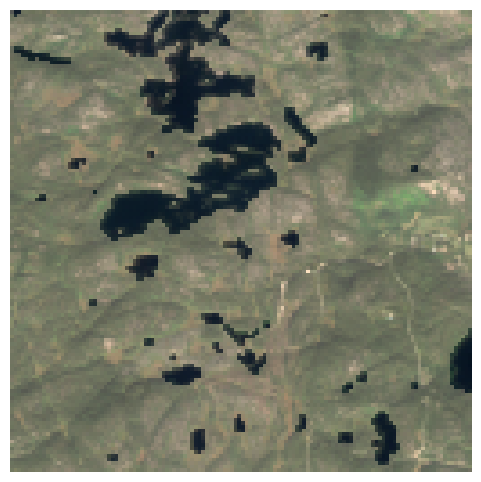

In [6]:
def plot_rgb(img, label=None):
    rgb = np.stack([img[3], img[2], img[1]], axis=-1)
    
    # Normalize for visualization
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    if label is not None:
        plt.imshow(label, cmap='Blues', alpha=0.3)  # overlay mask
    plt.axis('off')
    plt.show()

plot_rgb(img.numpy(), label.numpy())

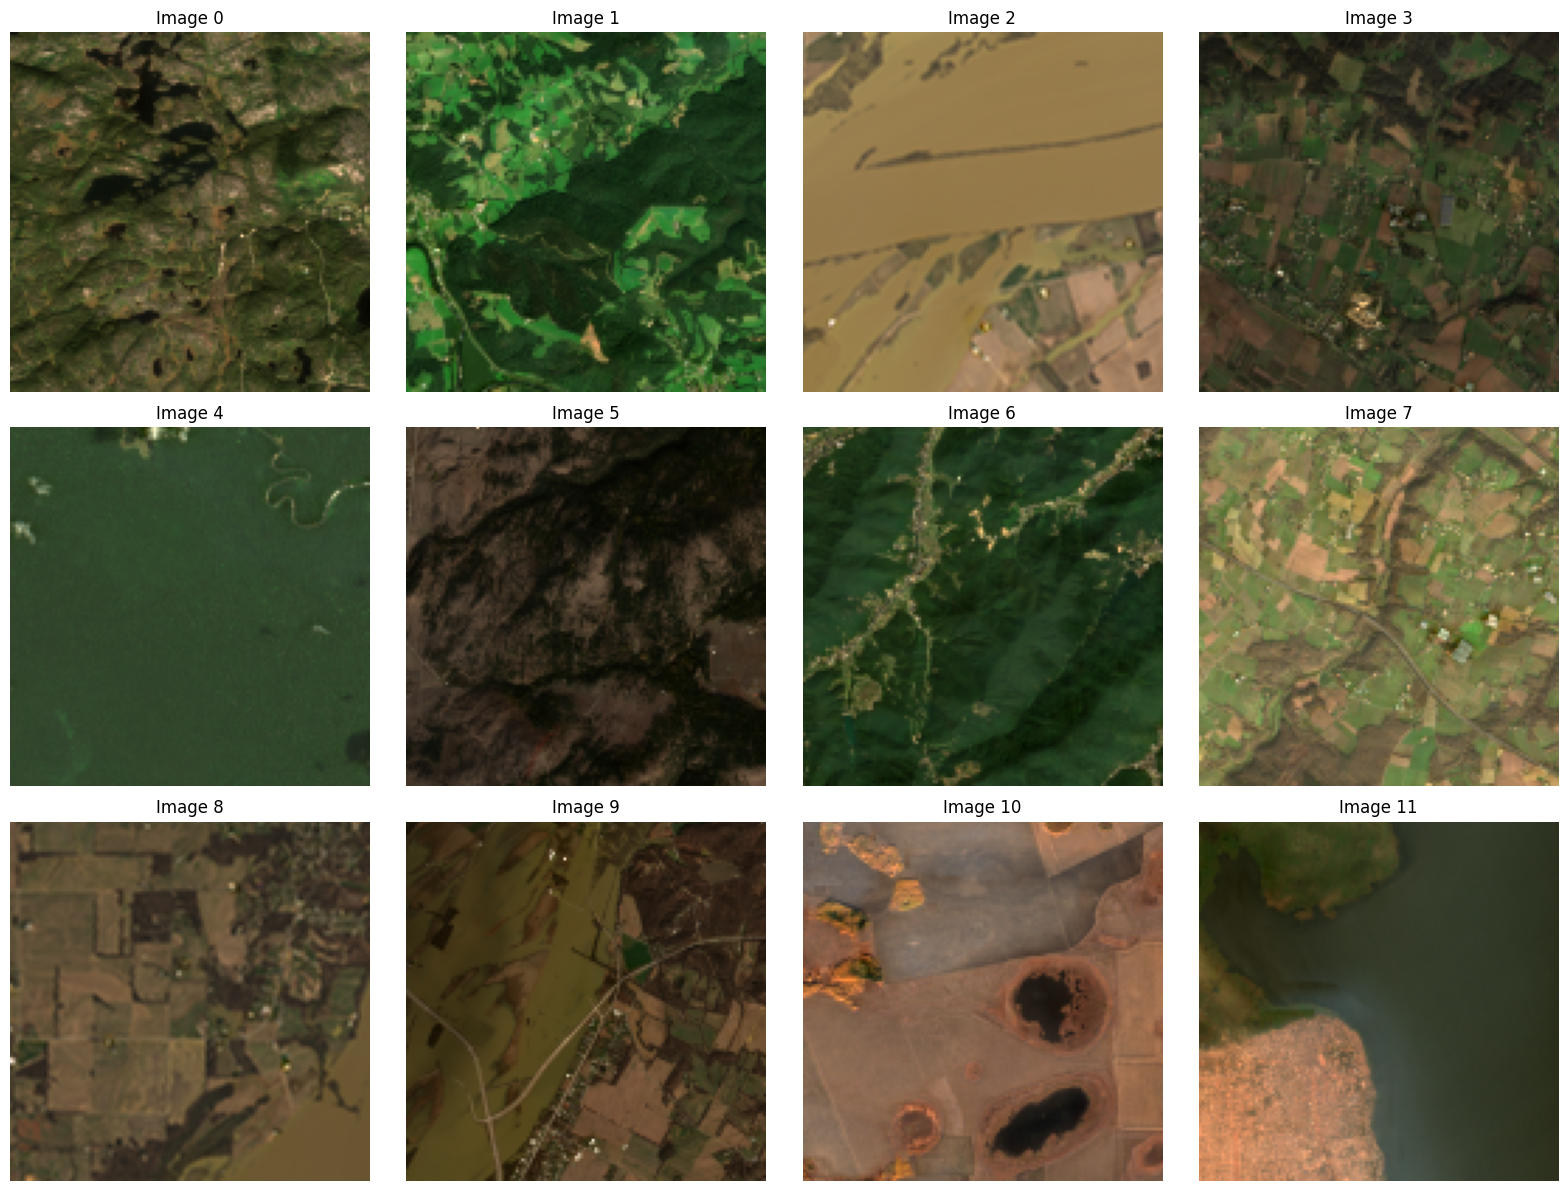

In [7]:
def plot_rgb_grid(dataset, indices=None, n_cols=4):
    """
    Display multiple RGB composites in a grid.
    
    Args:
        dataset: PyTorch dataset
        indices: list of indices to display (default: first n images)
        n_cols: number of columns in the grid
    """
    if indices is None:
        indices = list(range(min(8, len(dataset))))  # default: first 8 images
    
    n_rows = (len(indices) + n_cols - 1) // n_cols
    plt.figure(figsize=(4*n_cols, 4*n_rows))
    
    for i, idx in enumerate(indices):
        img, _ = dataset[idx]
        rgb = np.stack([img[3], img[2], img[1]], axis=-1)
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
        
        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(rgb)
        plt.title(f"Image {idx}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Example: visualize first 12 RGB images in a grid
plot_rgb_grid(dataset, indices=list(range(12)), n_cols=4)


# Preprocessing

In [8]:
from torch.utils.data import Subset, random_split

# Total number of samples
num_samples = len(dataset)

# Compute split sizes
train_size = int(0.7 * num_samples)
val_size = test_size = int(0.15 * num_samples)  # 45 each
train_size = num_samples - val_size - test_size  # 216

# Perform split
train_dataset, val_dataset, test_dataset = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)  # reproducible
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Train: 216, Val: 45, Test: 45


In [9]:
batch_size = 8

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [10]:
# Backup original transform
original_transform = train_dataset.dataset.transform  # if you wrapped Subset around base dataset

# Remove transform
train_dataset.dataset.transform = None

# Now compute band min/max
def compute_band_min_max(dataset):
    n_bands = 12
    band_min = np.full(n_bands, np.inf)
    band_max = np.full(n_bands, -np.inf)
    
    for img, _ in dataset:
        # Convert tensor to numpy if needed
        if isinstance(img, torch.Tensor):
            img = img.detach().cpu().numpy()
        
        band_min = np.minimum(band_min, img.reshape(n_bands, -1).min(axis=1))
        band_max = np.maximum(band_max, img.reshape(n_bands, -1).max(axis=1))
    
    return band_min, band_max

band_min, band_max = compute_band_min_max(train_dataset)
print("Band-wise min:", band_min)
print("Band-wise max:", band_max)

# Restore transform
train_dataset.dataset.transform = original_transform


Band-wise min: [-1.393e+03 -1.110e+03 -6.330e+02 -6.270e+02 -4.120e+02 -3.350e+02
 -2.580e+02  6.400e+01 -9.999e+03  8.000e+00  1.000e+01  0.000e+00]
Band-wise max: [ 6390.  9659. 11368. 12041. 15841. 15252. 14647.   255.  2784.  2762.
   100.   108.]


In [11]:
class NormalizedWaterDataset(Dataset):
    def __init__(self, base_dataset, band_min, band_max):
        self.base_dataset = base_dataset
        self.band_min = torch.tensor(band_min, dtype=torch.float32)[:, None, None]
        self.band_max = torch.tensor(band_max, dtype=torch.float32)[:, None, None]
        
    def __len__(self):
        return len(self.base_dataset)
    
    def __getitem__(self, idx):
        img, label = self.base_dataset[idx]
        # Ensure img is float tensor
        if not isinstance(img, torch.Tensor):
            img = torch.tensor(img, dtype=torch.float32)
        # Normalize
        img = (img - self.band_min) / (self.band_max - self.band_min + 1e-8)
        return img, label


In [12]:
train_dataset.dataset.transform = None
val_dataset.dataset.transform = None
test_dataset.dataset.transform = None

train_dataset_norm = NormalizedWaterDataset(train_dataset.dataset, band_min, band_max)
val_dataset_norm = NormalizedWaterDataset(val_dataset.dataset, band_min, band_max)
test_dataset_norm = NormalizedWaterDataset(test_dataset.dataset, band_min, band_max)

train_loader = DataLoader(train_dataset_norm, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset_norm, batch_size=8, shuffle=False)
test_loader = DataLoader(test_dataset_norm, batch_size=8, shuffle=False)


torch.Size([8, 12, 128, 128]) torch.Size([8, 128, 128])


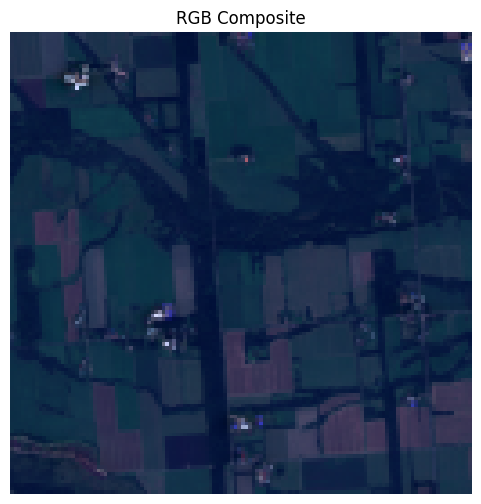

In [13]:
for imgs, labels in train_loader:
    print(imgs.shape, labels.shape)  # should be (batch_size, 12, 128, 128), (batch_size, 128, 128)
    plot_rgb_only(imgs[0].numpy())
    break


# Model Architecture

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, features=[64, 128, 256, 512]):
        super(UNet, self).__init__()
        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(2)

        # Downsampling
        for feature in features:
            self.downs.append(self.double_conv(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self.double_conv(features[-1], features[-1]*2)

        # Upsampling
        for feature in reversed(features):
            self.ups.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.ups.append(self.double_conv(feature*2, feature))

        # Final conv
        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.ups), 2):
            x = self.ups[idx](x)  # upsample
            skip_connection = skip_connections[idx//2]
            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])
            x = torch.cat((skip_connection, x), dim=1)
            x = self.ups[idx+1](x)  # conv

        return self.final_conv(x)

    @staticmethod
    def double_conv(in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

# Instantiate model
model = UNet(in_channels=12, out_channels=1)
print(model)


UNet(
  (downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm

In [15]:
from torchsummary import summary

# Move model to device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Print summary for input size [12, 128, 128]
summary(model, input_size=(12, 128, 128))


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           6,976
       BatchNorm2d-2         [-1, 64, 128, 128]             128
              ReLU-3         [-1, 64, 128, 128]               0
            Conv2d-4         [-1, 64, 128, 128]          36,928
       BatchNorm2d-5         [-1, 64, 128, 128]             128
              ReLU-6         [-1, 64, 128, 128]               0
         MaxPool2d-7           [-1, 64, 64, 64]               0
            Conv2d-8          [-1, 128, 64, 64]          73,856
       BatchNorm2d-9          [-1, 128, 64, 64]             256
             ReLU-10          [-1, 128, 64, 64]               0
           Conv2d-11          [-1, 128, 64, 64]         147,584
      BatchNorm2d-12          [-1, 128, 64, 64]             256
             ReLU-13          [-1, 128, 64, 64]               0
        MaxPool2d-14          [-1, 128,

In [16]:
import torch
import torch.nn as nn

# Loss function
criterion = nn.BCEWithLogitsLoss()

# Threshold for converting logits to binary masks
threshold = 0.5

# Metric functions
def compute_iou(preds, labels, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    intersection = (preds * labels).sum(dim=(1,2))
    union = (preds + labels - preds*labels).sum(dim=(1,2))
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou.mean().item()

def compute_f1(preds, labels, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    tp = (preds * labels).sum(dim=(1,2))
    fp = (preds * (1 - labels)).sum(dim=(1,2))
    fn = ((1 - preds) * labels).sum(dim=(1,2))
    f1 = 2 * tp / (2*tp + fp + fn + 1e-6)
    return f1.mean().item()

def compute_precision_recall(preds, labels, threshold=0.5):
    preds = (torch.sigmoid(preds) > threshold).float()
    tp = (preds * labels).sum(dim=(1,2))
    fp = (preds * (1 - labels)).sum(dim=(1,2))
    fn = ((1 - preds) * labels).sum(dim=(1,2))
    precision = (tp + 1e-6) / (tp + fp + 1e-6)
    recall = (tp + 1e-6) / (tp + fn + 1e-6)
    return precision.mean().item(), recall.mean().item()


In [17]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth

    def forward(self, logits, targets):
        """
        logits: [B,1,H,W], raw model output (before sigmoid)
        targets: [B,H,W] or [B,1,H,W], ground truth mask (0 or 1)
        """
        probs = torch.sigmoid(logits)  # convert logits to probabilities
        targets = targets.unsqueeze(1) if targets.dim() == 3 else targets  # ensure shape [B,1,H,W]
        
        intersection = (probs * targets).sum(dim=(2,3))
        union = probs.sum(dim=(2,3)) + targets.sum(dim=(2,3))
        
        dice_score = (2. * intersection + self.smooth) / (union + self.smooth)
        dice_loss = 1 - dice_score
        return dice_loss.mean()


In [18]:
bce_criterion = nn.BCEWithLogitsLoss()
dice_criterion = DiceLoss()

def combined_loss(logits, targets, bce_weight=0.5):
    bce_loss = bce_criterion(logits, targets.unsqueeze(1))
    dice_loss = dice_criterion(logits, targets)
    return bce_weight * bce_loss + (1 - bce_weight) * dice_loss


In [19]:
import torch.optim as optim

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# Number of epochs
num_epochs = 20
best_val_iou = 0.0

for epoch in range(num_epochs):
    # -------- Training --------
    model.train()
    train_loss = 0.0
    train_iou = 0.0
    train_f1 = 0.0
    train_precision = 0.0
    train_recall = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.float().to(device)
        
        optimizer.zero_grad()
        outputs = model(imgs)  # [B,1,H,W]
        loss = combined_loss(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * imgs.size(0)
        train_iou += compute_iou(outputs.squeeze(1), labels) * imgs.size(0)
        train_f1 += compute_f1(outputs.squeeze(1), labels) * imgs.size(0)
        precision, recall = compute_precision_recall(outputs.squeeze(1), labels)
        train_precision += precision * imgs.size(0)
        train_recall += recall * imgs.size(0)
    
    train_loss /= len(train_loader.dataset)
    train_iou /= len(train_loader.dataset)
    train_f1 /= len(train_loader.dataset)
    train_precision /= len(train_loader.dataset)
    train_recall /= len(train_loader.dataset)
    
    # -------- Validation --------
    model.eval()
    val_loss = 0.0
    val_iou = 0.0
    val_f1 = 0.0
    val_precision = 0.0
    val_recall = 0.0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.float().to(device)
            outputs = model(imgs)
            loss = combined_loss(outputs, labels)
            
            val_loss += loss.item() * imgs.size(0)
            val_iou += compute_iou(outputs.squeeze(1), labels) * imgs.size(0)
            val_f1 += compute_f1(outputs.squeeze(1), labels) * imgs.size(0)
            precision, recall = compute_precision_recall(outputs.squeeze(1), labels)
            val_precision += precision * imgs.size(0)
            val_recall += recall * imgs.size(0)
    
    val_loss /= len(val_loader.dataset)
    val_iou /= len(val_loader.dataset)
    val_f1 /= len(val_loader.dataset)
    val_precision /= len(val_loader.dataset)
    val_recall /= len(val_loader.dataset)
    
    # Save best model
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save(model.state_dict(), "best_unet_bce_dice.pth")
    
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f}, IoU: {train_iou:.4f}, F1: {train_f1:.4f}, "
          f"Precision: {train_precision:.4f}, Recall: {train_recall:.4f} | "
          f"Val Loss: {val_loss:.4f}, IoU: {val_iou:.4f}, F1: {val_f1:.4f}, "
          f"Precision: {val_precision:.4f}, Recall: {val_recall:.4f}")


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Epoch [1/20] Train Loss: 0.5453, IoU: 0.4477, F1: 0.4476, Precision: 0.6433, Recall: 0.6789 | Val Loss: 0.5133, IoU: 0.4739, F1: 0.4429, Precision: 0.7822, Recall: 0.5946
Epoch [2/20] Train Loss: 0.5025, IoU: 0.4799, F1: 0.4685, Precision: 0.7186, Recall: 0.6599 | Val Loss: 0.4987, IoU: 0.4793, F1: 0.4688, Precision: 0.7008, Recall: 0.6615
Epoch [3/20] Train Loss: 0.4770, IoU: 0.4911, F1: 0.4745, Precision: 0.7687, Recall: 0.6237 | Val Loss: 0.4737, IoU: 0.5177, F1: 0.4816, Precision: 0.8679, Recall: 0.5869
Epoch [4/20] Train Loss: 0.4795, IoU: 0.4893, F1: 0.4711, Precision: 0.7533, Recall: 0.6439 | Val Loss: 0.4546, IoU: 0.5119, F1: 0.4874, Precision: 0.7624, Recall: 0.6402
Epoch [5/20] Train Loss: 0.4742, IoU: 0.4998, F1: 0.4767, Precision: 0.7580, Recall: 0.6379 | Val Loss: 0.4762, IoU: 0.5107, F1: 0.4597, Precision: 0.9174, Recall: 0.5546
Epoch [6/20] Train Loss: 0.4768, IoU: 0.5164, F1: 0.4867, Precision: 0.7859, Recall: 0.6401 | Val Loss: 0.4568, IoU: 0.5390, F1: 0.4946, Precisio

In [20]:
model.load_state_dict(torch.load("best_unet_bce_dice.pth"))
model.eval()

UNet(
  (downs): ModuleList(
    (0): Sequential(
      (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm

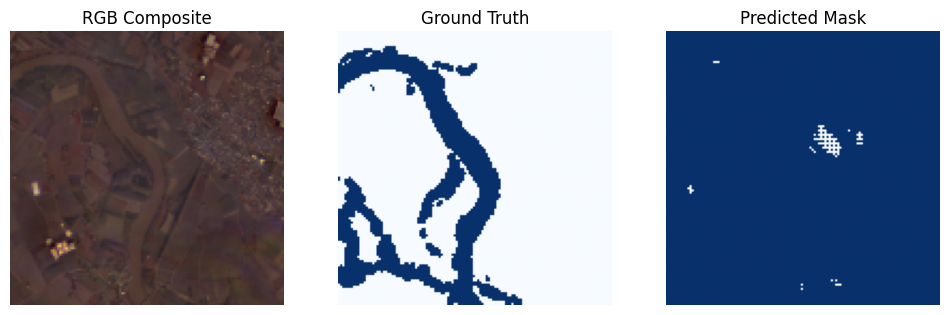

In [21]:
def visualize_prediction(img_tensor, label_tensor, model, threshold=0.5):
    model.eval()
    with torch.no_grad():
        img = img_tensor.unsqueeze(0).to(device)  # Add batch dim
        output = model(img)
        pred_mask = torch.sigmoid(output.squeeze(0))  # [1,H,W]
        pred_mask = (pred_mask > threshold).cpu().numpy().squeeze()  # now [H,W]

    # RGB composite from Red, Green, Blue bands
    img_rgb = img_tensor[[2,1,0],:,:].cpu().numpy()  # R,G,B
    img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())  # normalize
    img_rgb = np.transpose(img_rgb, (1,2,0))  # H,W,C for imshow

    fig, axs = plt.subplots(1,3, figsize=(12,4))
    axs[0].imshow(img_rgb)
    axs[0].set_title("RGB Composite")
    axs[0].axis('off')

    axs[1].imshow(label_tensor.cpu().numpy(), cmap='Blues')
    axs[1].set_title("Ground Truth")
    axs[1].axis('off')

    axs[2].imshow(pred_mask, cmap='Blues')
    axs[2].set_title("Predicted Mask")
    axs[2].axis('off')

    plt.show()

# Example: visualize first image in test dataset
test_img, test_label = test_dataset[5]
visualize_prediction(test_img, test_label, model)


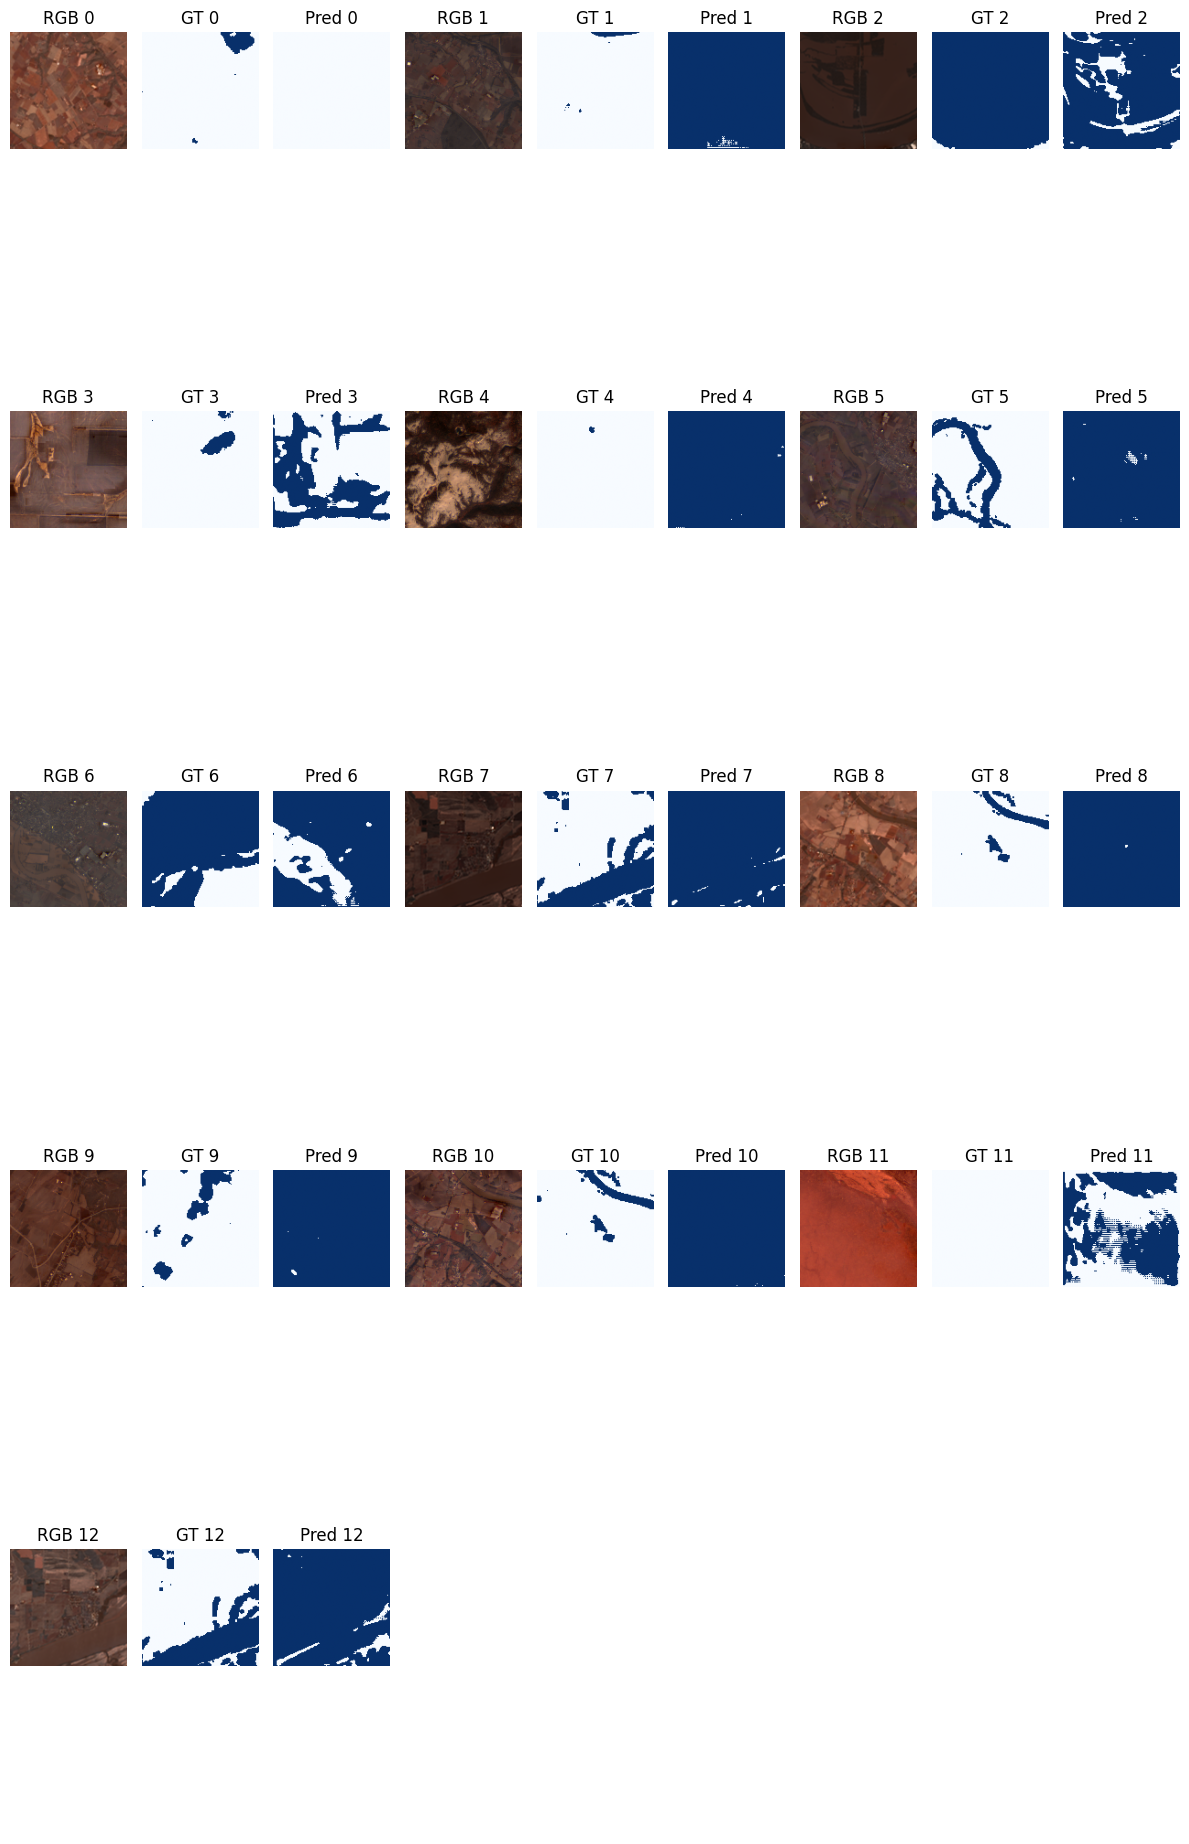

In [22]:
def visualize_multiple_predictions(dataset, model, indices, threshold=0.5, ncols=3):

    model.eval()
    n = len(indices)
    nrows = int(np.ceil(n / ncols))
    fig, axs = plt.subplots(nrows, ncols*3, figsize=(ncols*4, nrows*4))
    axs = axs.flatten()  # flatten for easy indexing

    for i, idx in enumerate(indices):
        img_tensor, label_tensor = dataset[idx]
        with torch.no_grad():
            img = img_tensor.unsqueeze(0).to(device)
            output = model(img)
            pred_mask = torch.sigmoid(output.squeeze(0))  # [1,H,W]
            pred_mask = (pred_mask > threshold).cpu().numpy().squeeze()  # [H,W]

        # RGB composite
        img_rgb = img_tensor[[2,1,0],:,:].cpu().numpy()  # R,G,B
        img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())
        img_rgb = np.transpose(img_rgb, (1,2,0))  # H,W,3

        axs[i*3].imshow(img_rgb)
        axs[i*3].set_title(f"RGB {idx}")
        axs[i*3].axis('off')

        axs[i*3+1].imshow(label_tensor.cpu().numpy(), cmap='Blues')
        axs[i*3+1].set_title(f"GT {idx}")
        axs[i*3+1].axis('off')

        axs[i*3+2].imshow(pred_mask, cmap='Blues')
        axs[i*3+2].set_title(f"Pred {idx}")
        axs[i*3+2].axis('off')

    # Hide unused subplots
    for j in range(n*3, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()


# Example: visualize first 6 test samples
visualize_multiple_predictions(test_dataset, model, indices=[0,1,2,3,4,5,6,7,8,9,10,11,12], ncols=3)
